In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("DATA/student_dropout_dataset.csv")

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (10000, 19)


In [3]:
print(df.columns.tolist())
print()
print(df.head())
print()
print(df.tail())
print()
print(df.info())

['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout']

   Student_ID   Age  Gender  Family_Income Internet_Access  \
0           1  22.1    Male        25000.0             Yes   
1           2  20.7    Male        25000.0             Yes   
2           3  22.4    Male        40183.0             Yes   
3           4  24.4    Male            NaN             Yes   
4           5  20.5  Female        25319.0             Yes   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70.9                      0   
3                  NaN             82.2                      2   


In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

Columns with missing values:
Family_Income          500
Study_Hours_per_Day    500
Stress_Index           500
Parental_Education     511
dtype: int64


In [5]:
print(df["Dropout"].value_counts())
print()
print(df["Dropout"].value_counts(normalize=True) * 100)

Dropout
0    7646
1    2354
Name: count, dtype: int64

Dropout
0    76.46
1    23.54
Name: proportion, dtype: float64


In [6]:
print(df.dtypes)
print("\nNumerical columns:")
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include=["object", "category", "bool"]).columns.tolist())

Student_ID                 int64
Age                      float64
Gender                       str
Family_Income            float64
Internet_Access              str
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job                str
Scholarship                  str
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                     str
Department                   str
Parental_Education           str
Dropout                    int64
dtype: object

Numerical columns:
['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Dropout']

Categorical columns:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


C:\Users\Vanshika\AppData\Local\Temp\ipykernel_9876\60631361.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=["object", "category", "bool"]).columns.tolist())


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.50,7500.25,10000.00
Age,10000.0,21.026060,2.139810,17.0,19.50,21.00,22.50,29.60
Family_Income,9500.0,38377.247474,20496.232179,25000.0,25000.00,29740.50,44520.00,316601.00
Study_Hours_per_Day,9500.0,4.014592,1.295450,0.5,3.16,4.00,4.87,8.98
Attendance_Rate,10000.0,81.736830,8.220930,38.2,76.40,81.80,87.30,100.00
Assignment_Delay_Days,10000.0,1.799700,1.344307,0.0,1.00,2.00,3.00,8.00
Travel_Time_Minutes,10000.0,30.179260,11.918870,5.0,21.90,30.20,38.40,74.90
Stress_Index,9500.0,5.507147,1.765951,1.0,4.30,5.50,6.70,10.00
GPA,10000.0,2.308440,1.061717,0.0,1.55,2.35,3.12,4.00
Semester_GPA,10000.0,2.300057,1.074407,0.0,1.52,2.35,3.15,4.00


In [9]:
for col in df.select_dtypes(include=["object", "category", "bool"]).columns:
    print("\n" + "=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False))


Gender
Gender
Female    5011
Male      4989
Name: count, dtype: int64

Internet_Access
Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

Part_Time_Job
Part_Time_Job
No     5996
Yes    4004
Name: count, dtype: int64

Scholarship
Scholarship
No     6489
Yes    3511
Name: count, dtype: int64

Semester
Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455
Name: count, dtype: int64

Department
Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937
Name: count, dtype: int64

Parental_Education
Parental_Education
Bachelor       3949
High School    3072
Master         2003
NaN             511
PhD             465
Name: count, dtype: int64


C:\Users\Vanshika\AppData\Local\Temp\ipykernel_9876\1015725974.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object", "category", "bool"]).columns:


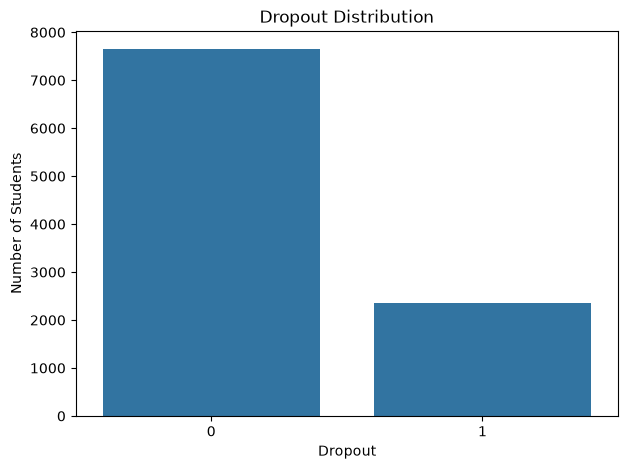

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Dropout"
)

plt.title("Dropout Distribution")
plt.xlabel("Dropout")
plt.ylabel("Number of Students")

plt.show()

In [11]:
target_summary = pd.DataFrame({
    "Count": df["Dropout"].value_counts(),
    "Percentage": df["Dropout"].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
Dropout,,
0,7646,76.46
1,2354,23.54


In [12]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
for column in numeric_columns:
    print("-", column)

Numerical columns:
- Student_ID
- Age
- Family_Income
- Study_Hours_per_Day
- Attendance_Rate
- Assignment_Delay_Days
- Travel_Time_Minutes
- Stress_Index
- GPA
- Semester_GPA
- CGPA
- Dropout


In [20]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:")
for column in categorical_columns:
    print("-", column)

Categorical columns:
- Gender
- Internet_Access
- Part_Time_Job
- Scholarship
- Semester
- Department
- Parental_Education


C:\Users\Vanshika\AppData\Local\Temp\ipykernel_9876\3392652052.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [13]:
unique_summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Unique_Values": df.nunique(),
    "Missing_Values": df.isnull().sum()
})

unique_summary

,Data_Type,Unique_Values,Missing_Values
Student_ID,int64,10000,0
Age,float64,115,0
Gender,str,2,0
Family_Income,float64,5438,500
Internet_Access,str,2,0
Study_Hours_per_Day,float64,702,500
Attendance_Rate,float64,444,0
Assignment_Delay_Days,int64,9,0
Travel_Time_Minutes,float64,589,0
Part_Time_Job,str,2,0


In [14]:
unique_summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Unique_Values": df.nunique(),
    "Missing_Values": df.isnull().sum()
})

unique_summary

,Data_Type,Unique_Values,Missing_Values
Student_ID,int64,10000,0
Age,float64,115,0
Gender,str,2,0
Family_Income,float64,5438,500
Internet_Access,str,2,0
Study_Hours_per_Day,float64,702,500
Attendance_Rate,float64,444,0
Assignment_Delay_Days,int64,9,0
Travel_Time_Minutes,float64,589,0
Part_Time_Job,str,2,0


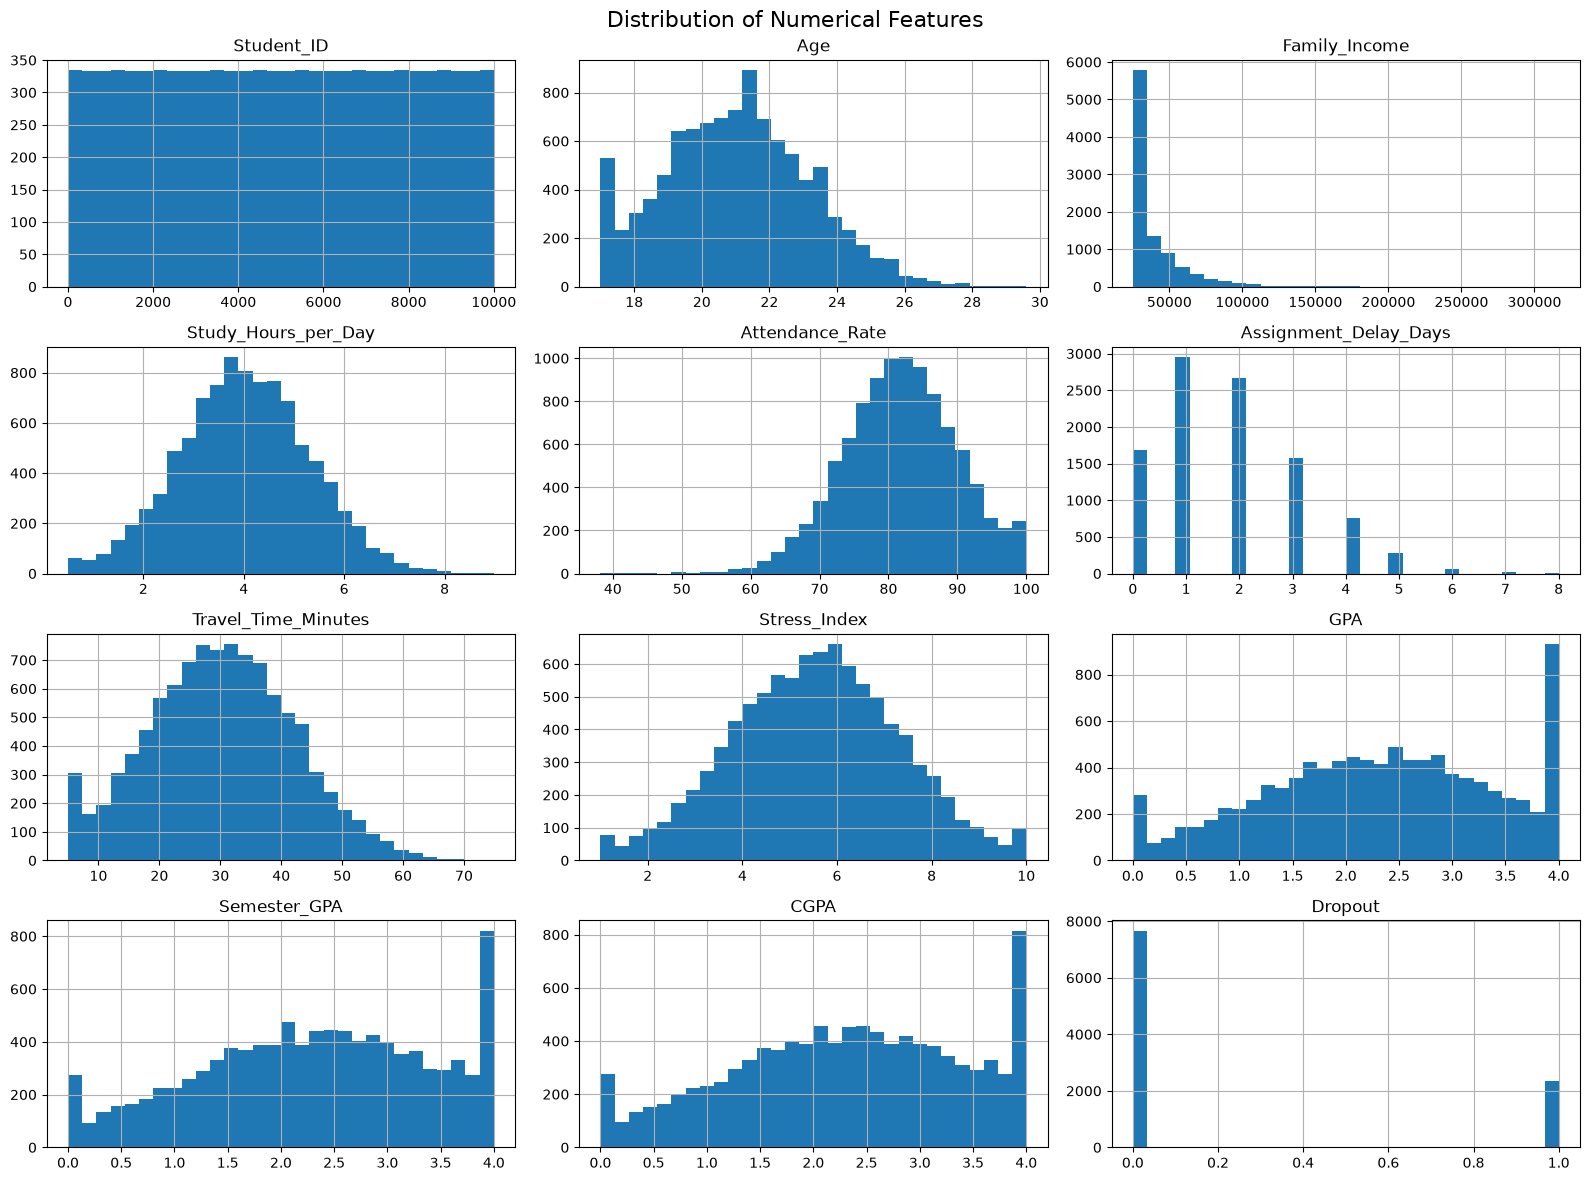

In [15]:
df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

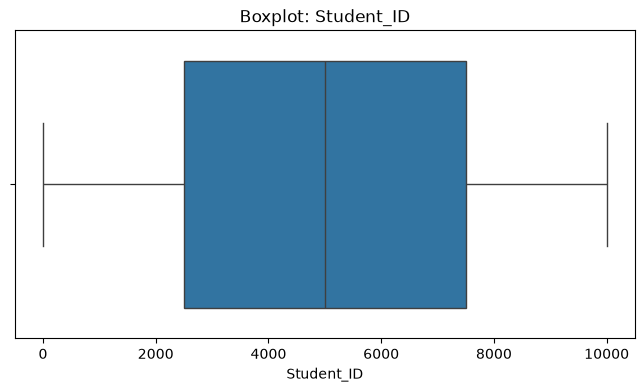

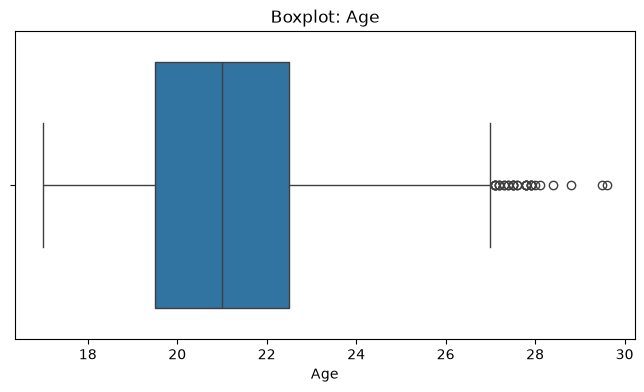

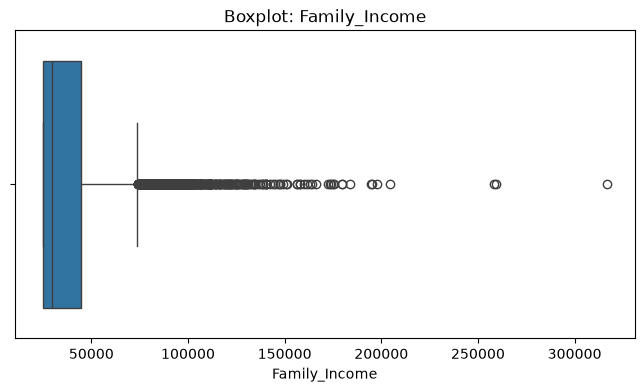

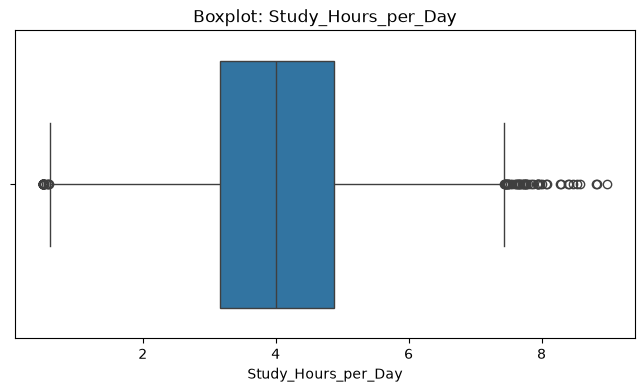

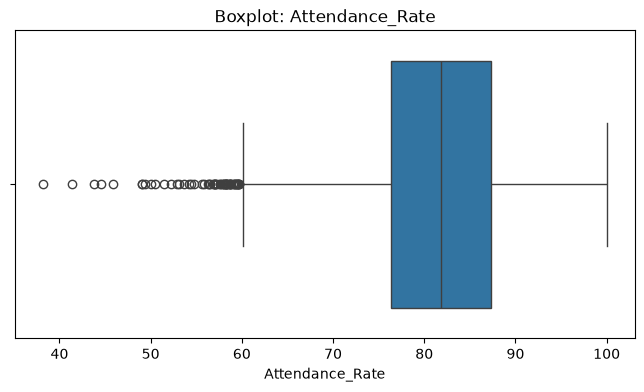

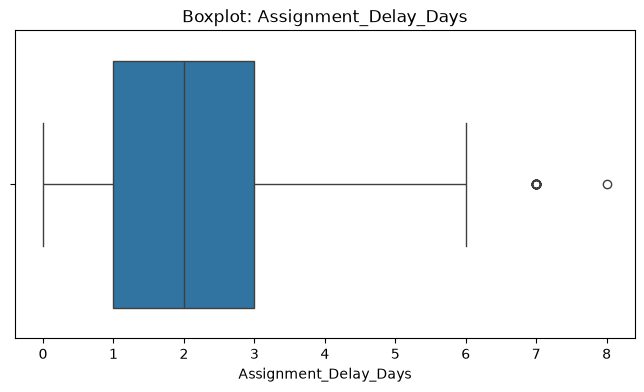

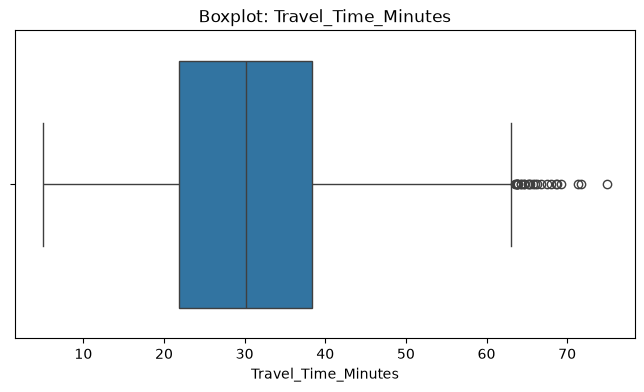

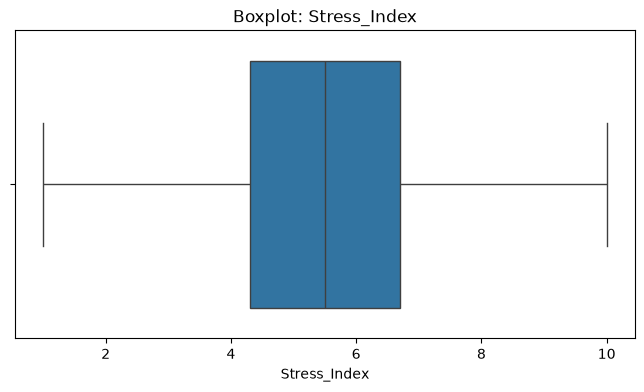

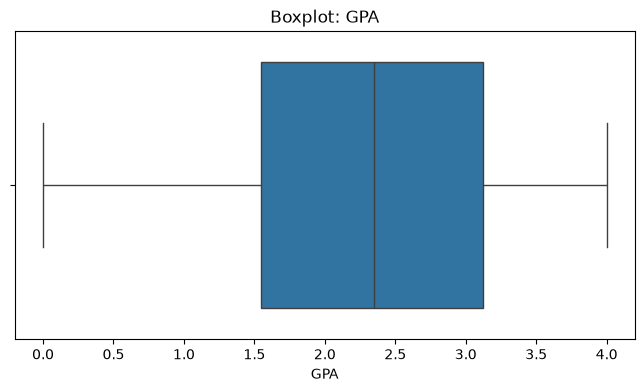

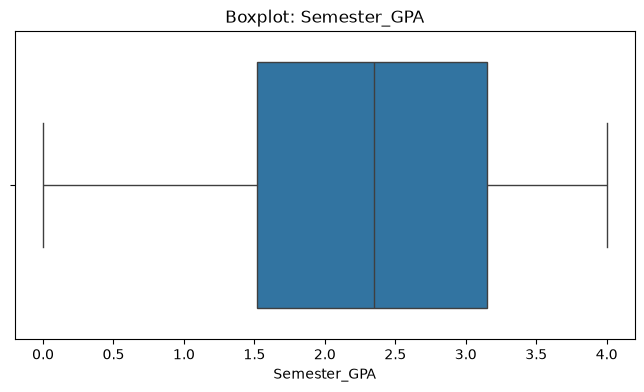

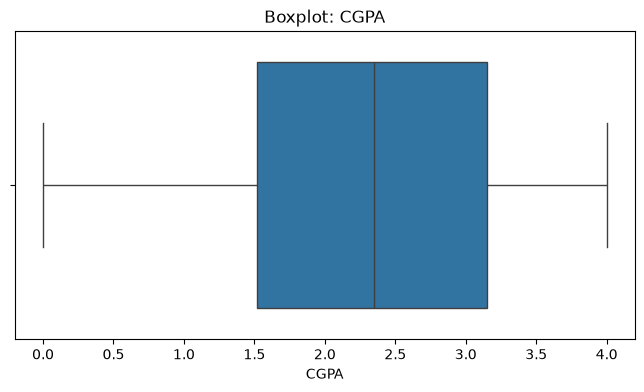

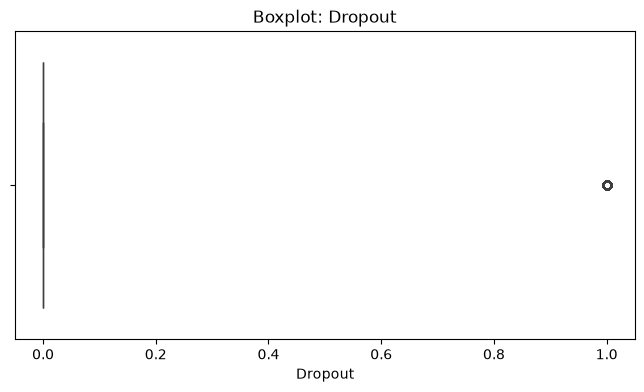

In [16]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot: {column}")
    plt.xlabel(column)

    plt.show()

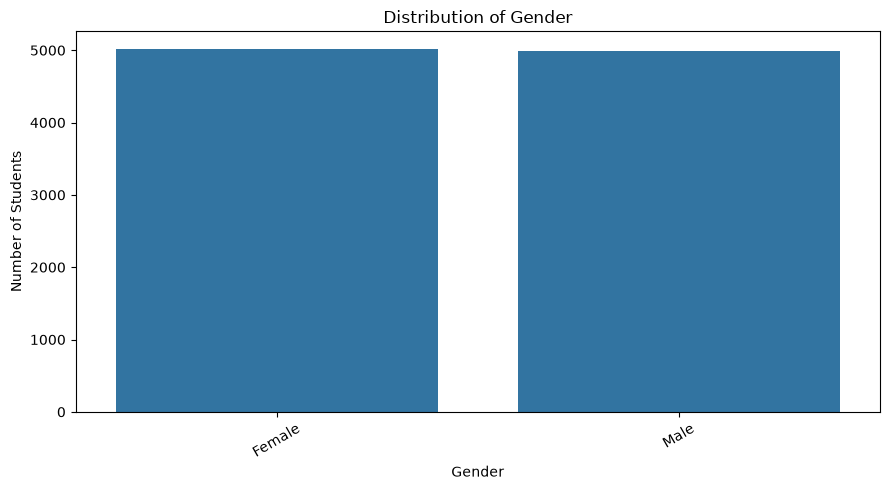

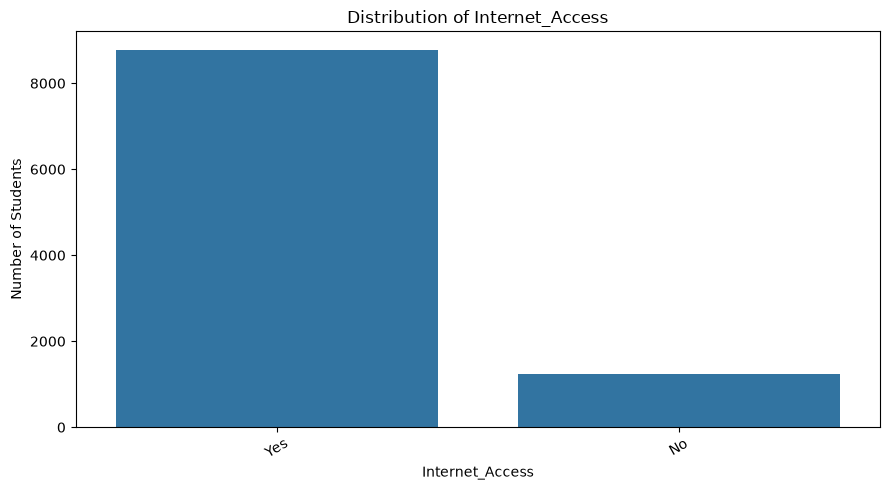

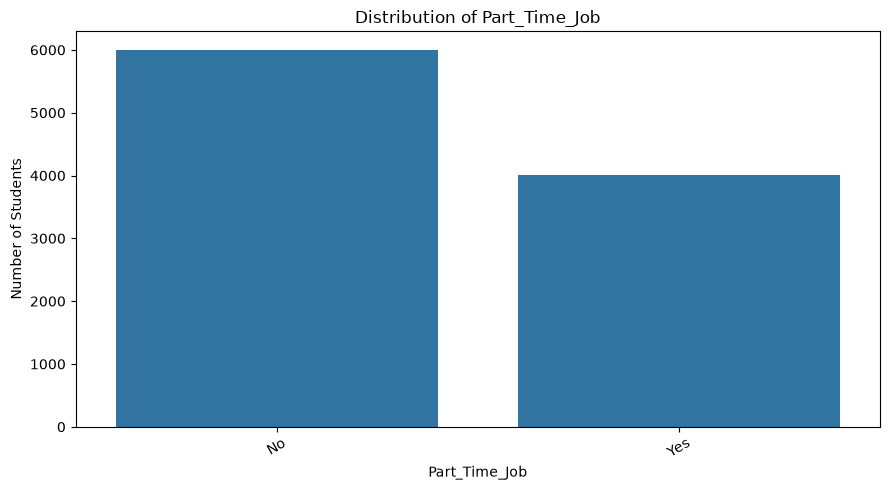

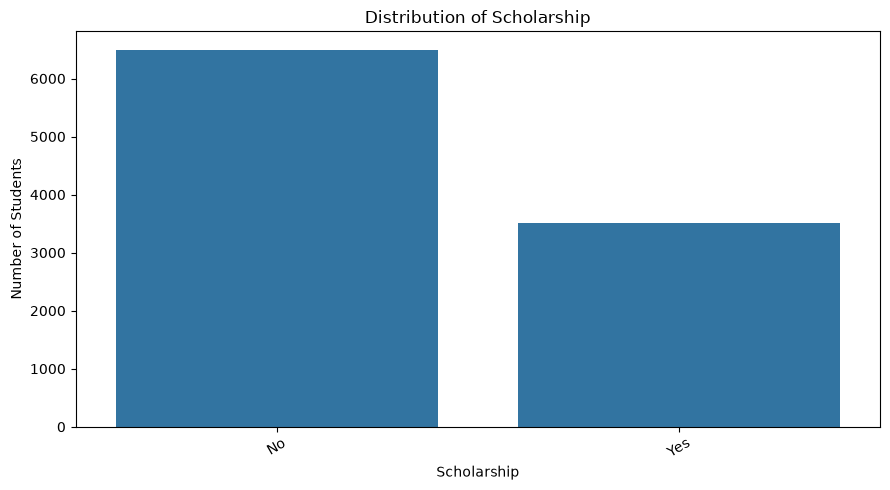

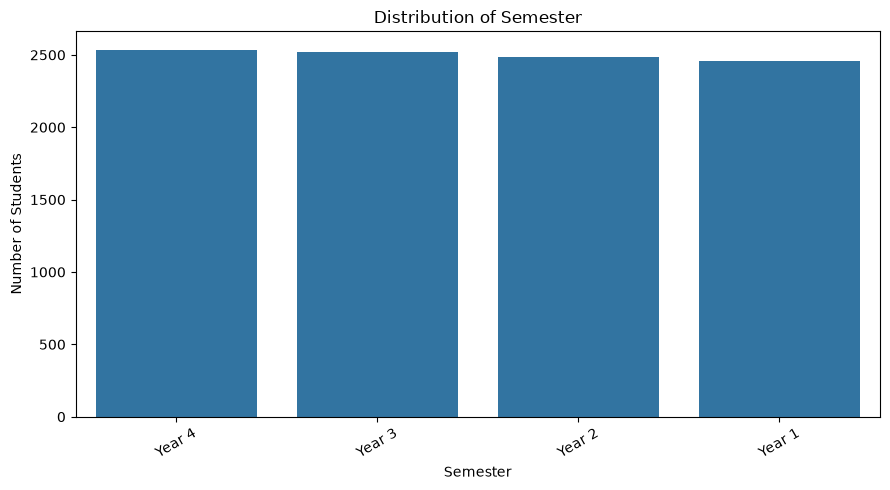

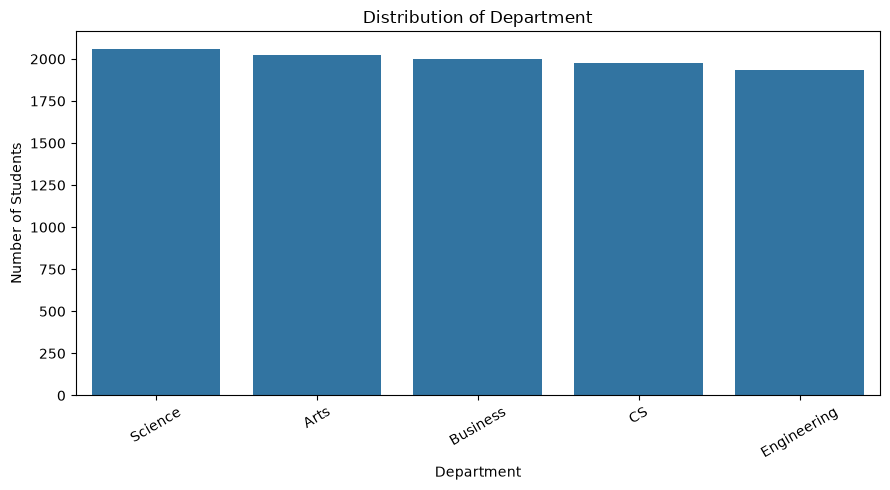

TypeError: 'value' must be an instance of str or bytes, not a float

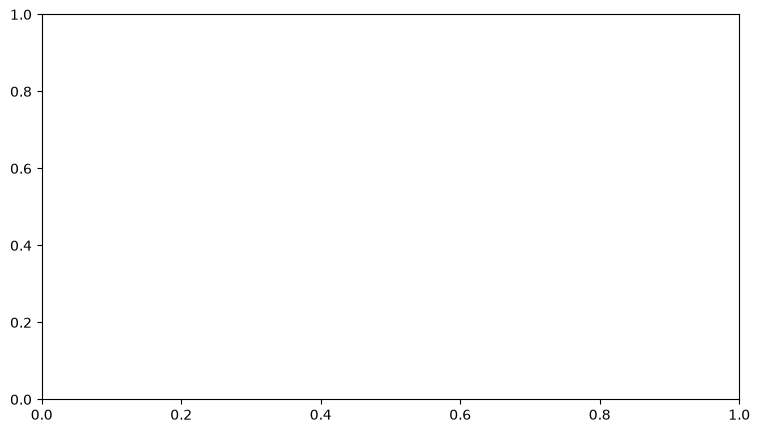

In [21]:
for column in categorical_columns:

    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts(dropna=False).index
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

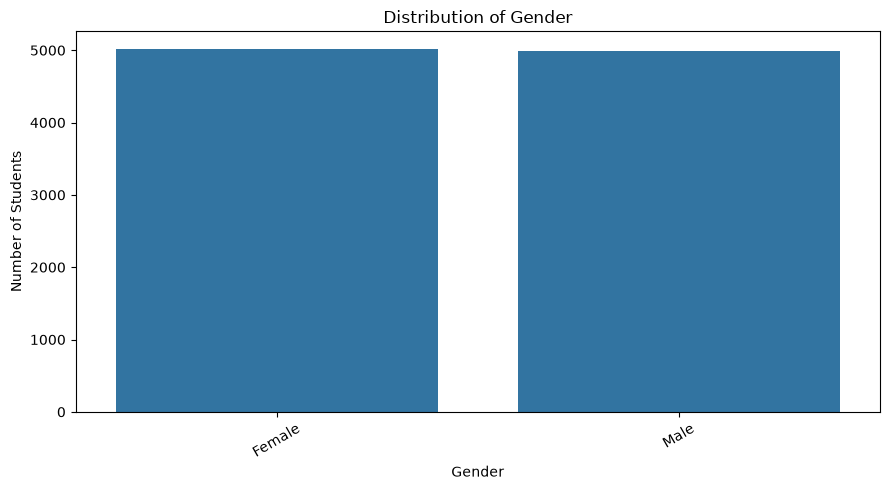

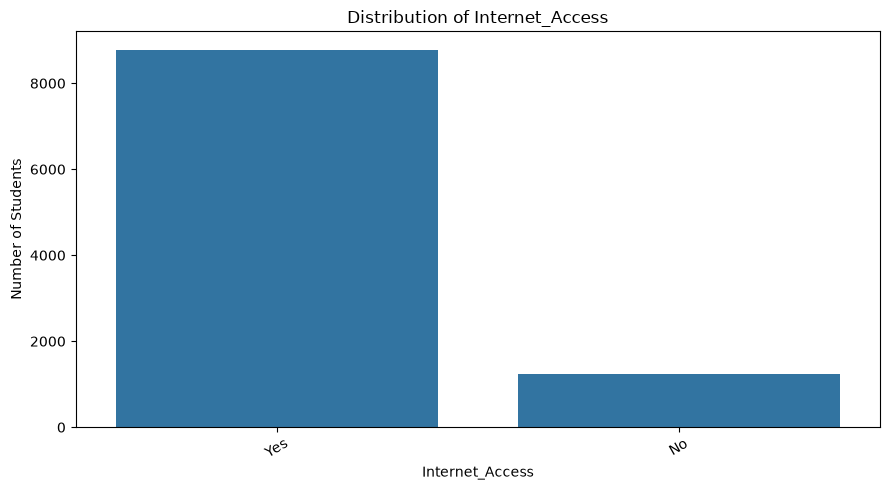

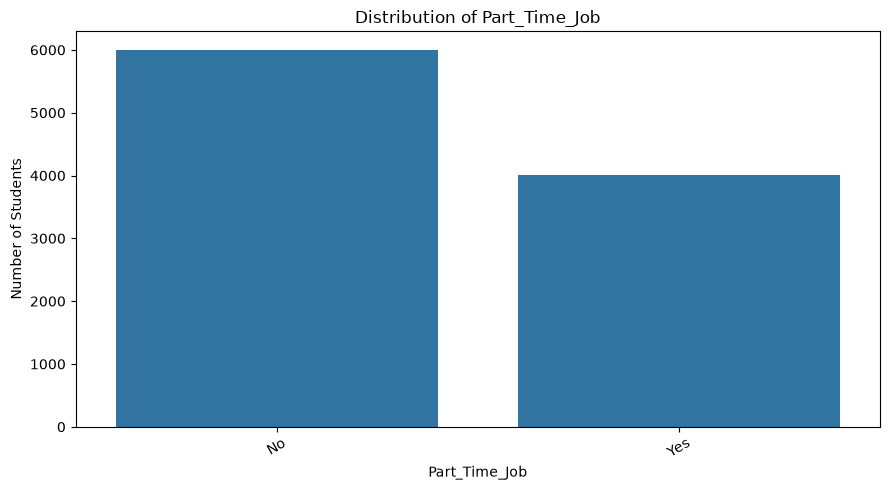

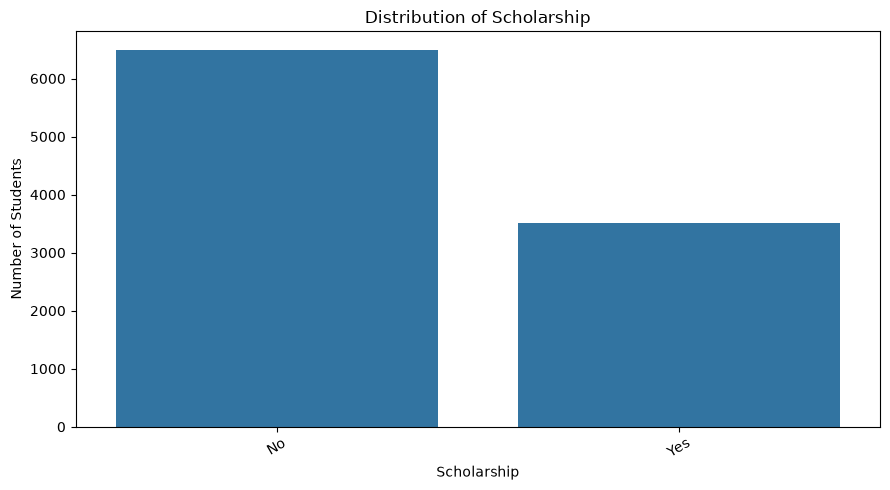

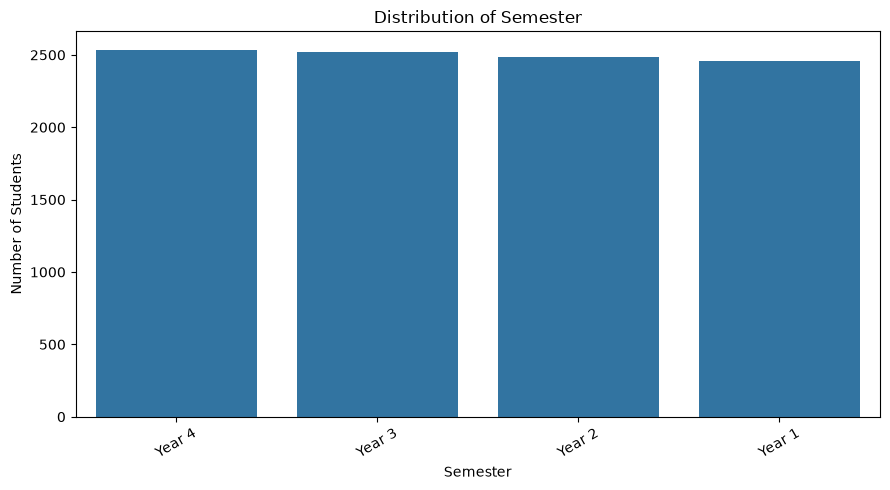

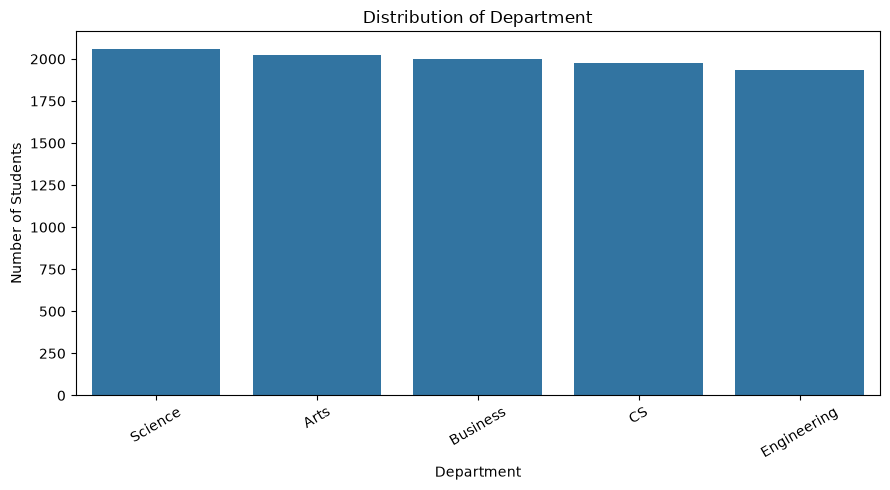

TypeError: 'value' must be an instance of str or bytes, not a float

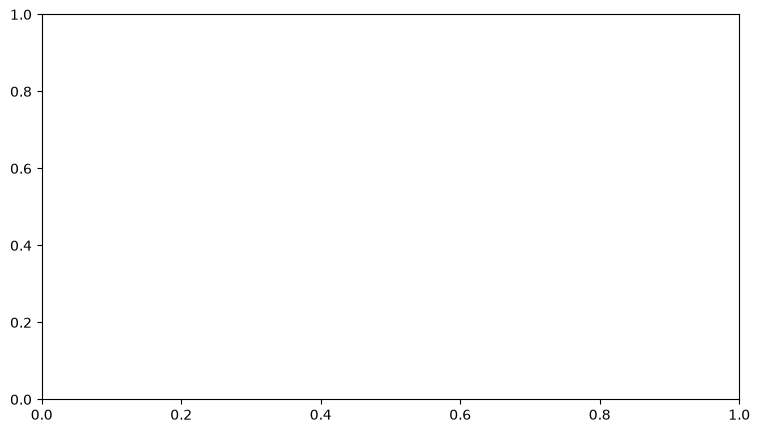

In [22]:
for column in categorical_columns:

    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts(dropna=False).index
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

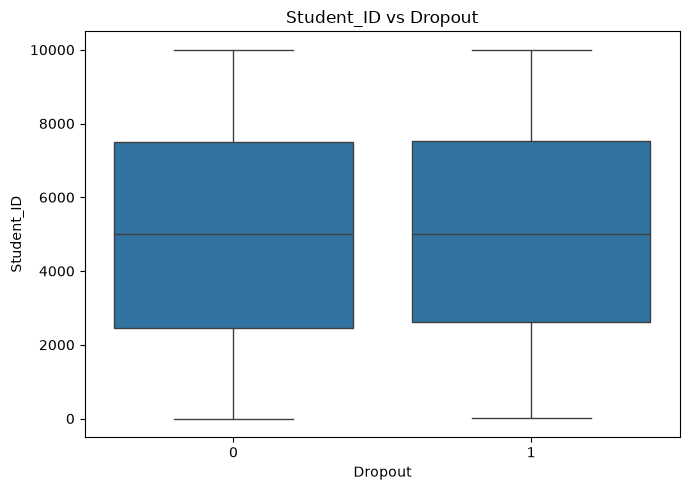

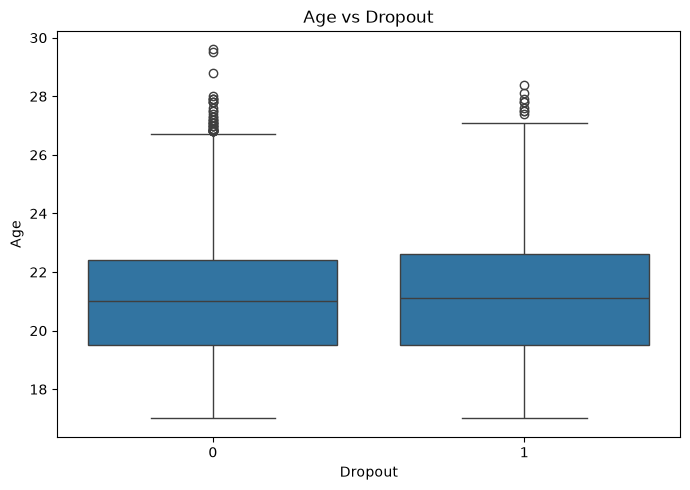

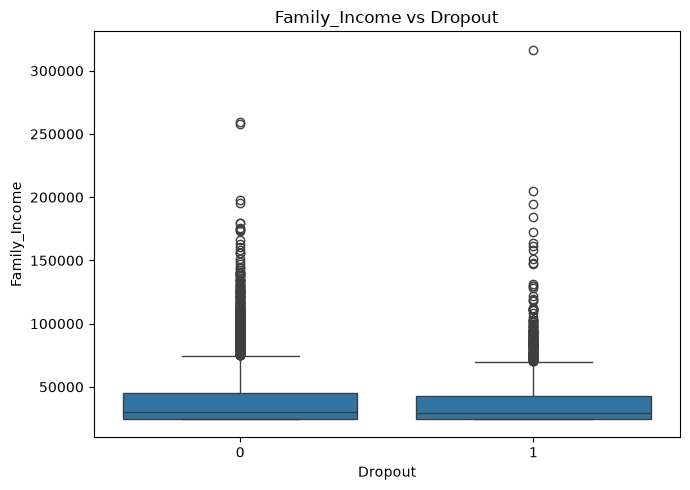

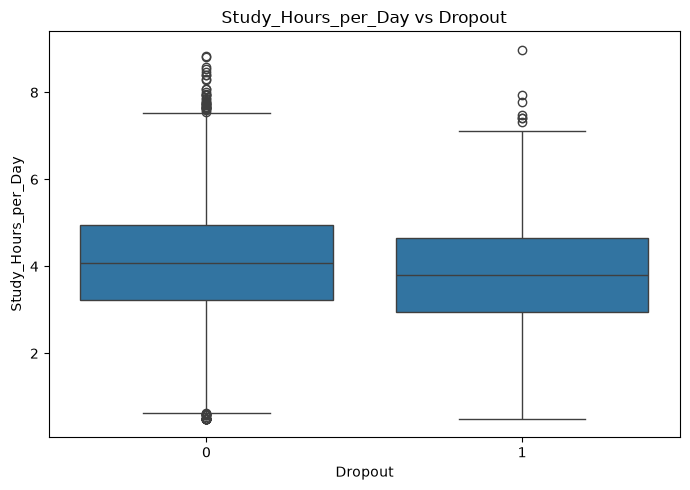

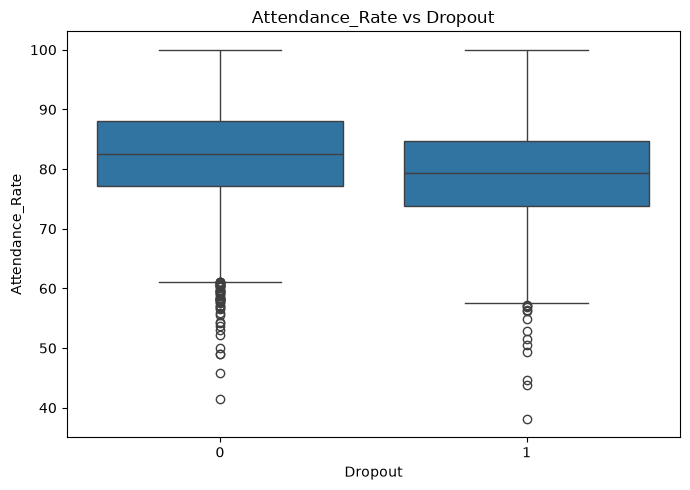

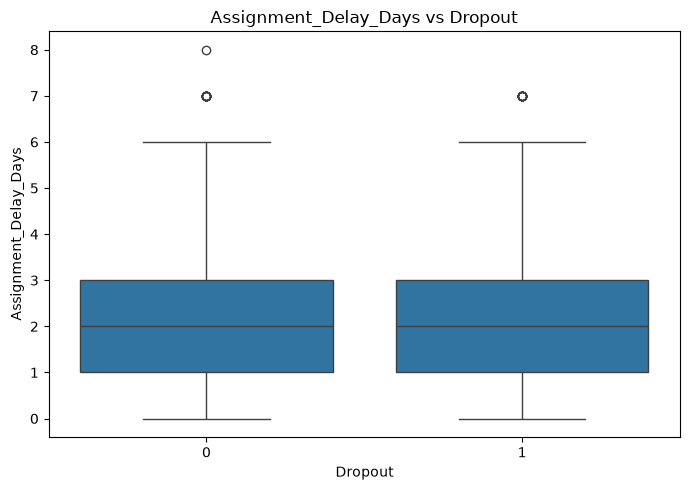

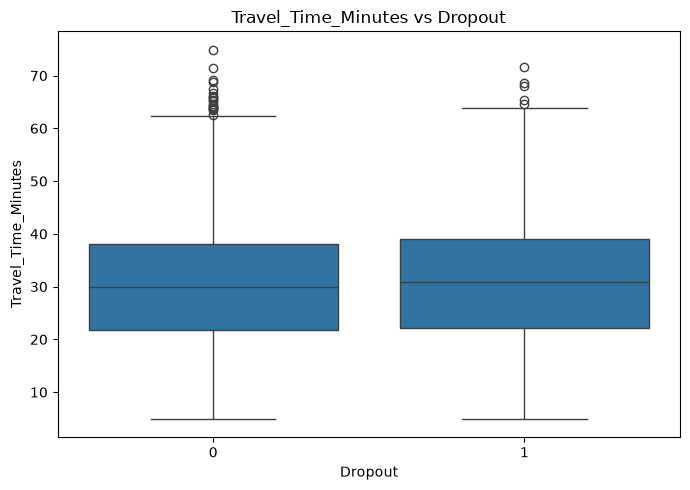

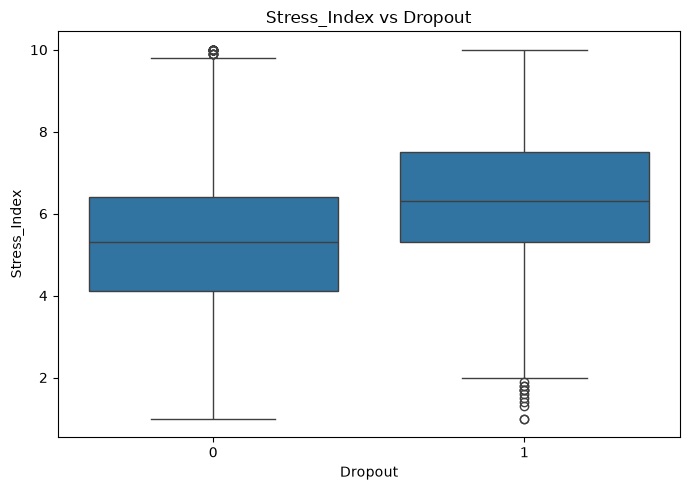

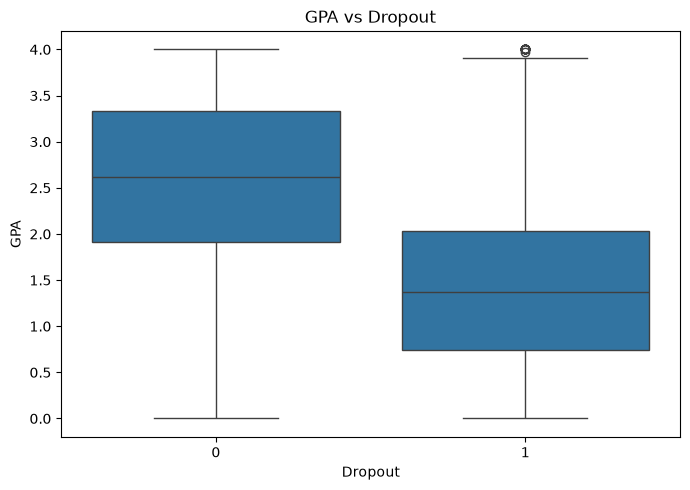

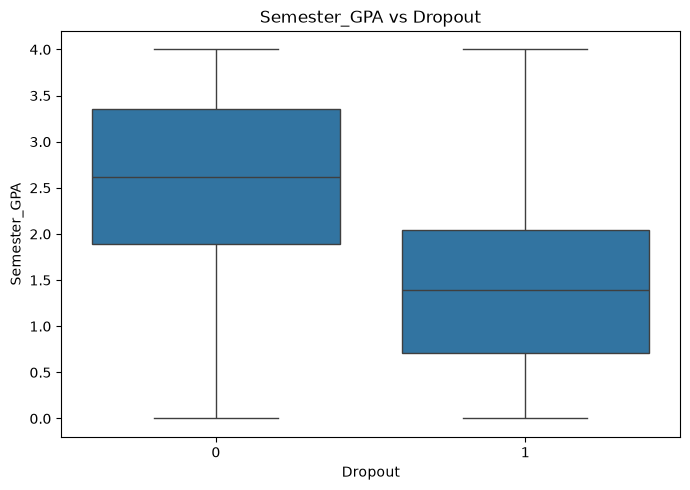

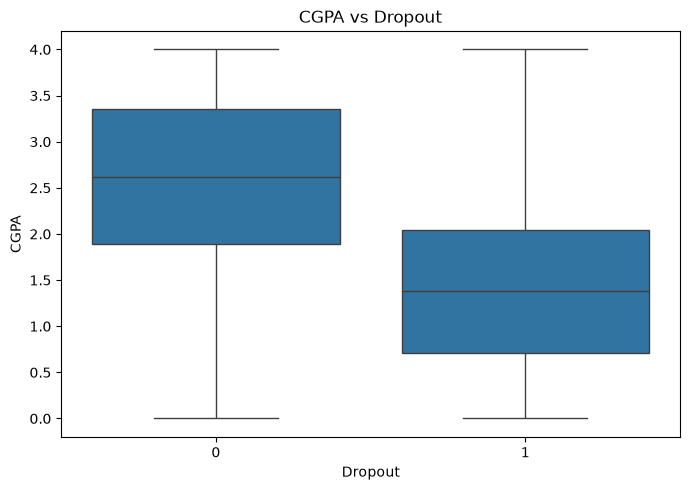

In [23]:
for column in numeric_columns:

    if column == "Dropout":
        continue

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Dropout",
        y=column
    )

    plt.title(f"{column} vs Dropout")
    plt.xlabel("Dropout")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [24]:
correlation_with_dropout = (
    df[numeric_columns]
    .corr()["Dropout"]
    .sort_values(ascending=False)
)

correlation_with_dropout

Dropout                  1.000000
Stress_Index             0.255648
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Age                      0.007585
Student_ID               0.007434
Family_Income           -0.011123
Study_Hours_per_Day     -0.089376
Attendance_Rate         -0.163539
CGPA                    -0.444807
Semester_GPA            -0.445396
GPA                     -0.460352
Name: Dropout, dtype: float64

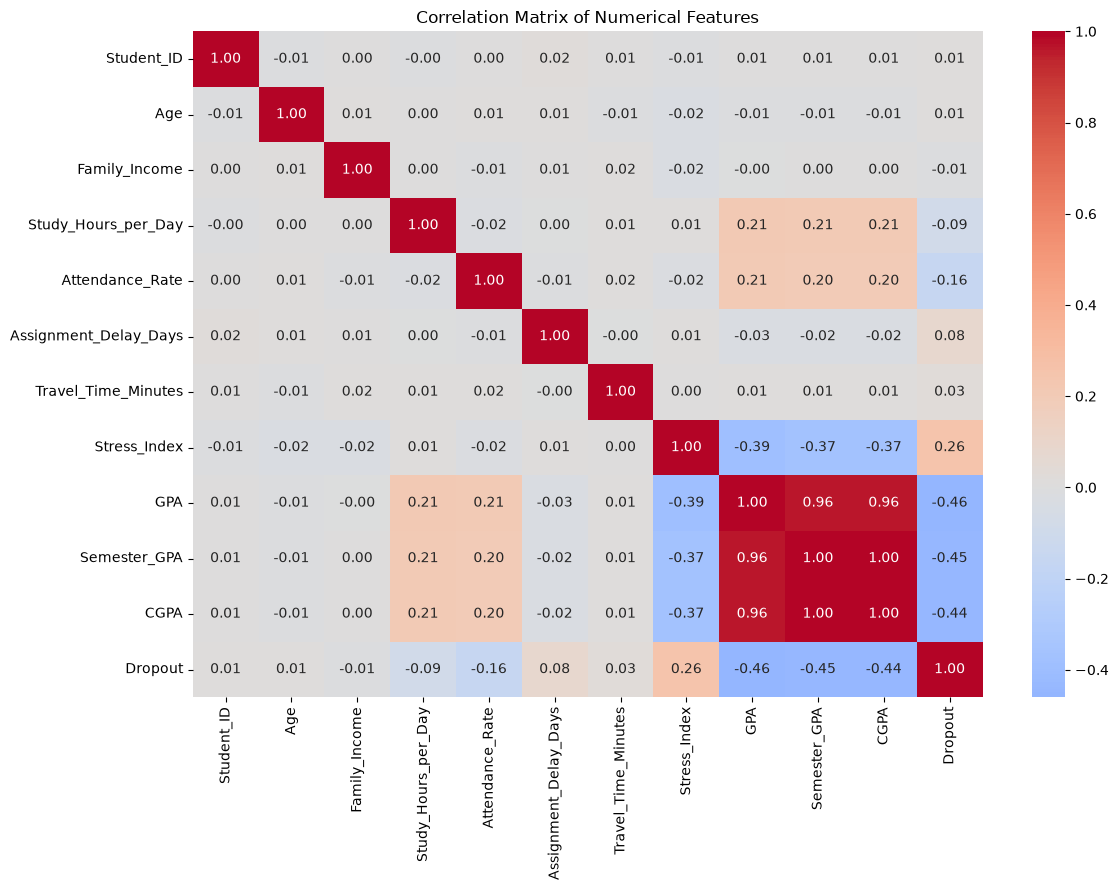

In [25]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [26]:
print("Total students:", len(df))
print("Unique Student IDs:", df["Student_ID"].nunique())

Total students: 10000
Unique Student IDs: 10000


In [27]:
for column in df.columns:
    unique_ratio = df[column].nunique() / len(df)

    if unique_ratio > 0.9:
        print(
            f"{column}: "
            f"{df[column].nunique()} unique values "
            f"({unique_ratio:.2%})"
        )

Student_ID: 10000 unique values (100.00%)


In [28]:
for column in categorical_columns:

    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)

    result = pd.crosstab(
        df[column],
        df["Dropout"],
        normalize="index"
    ) * 100

    print(result)


Gender
Dropout          0          1
Gender                       
Female   76.152465  23.847535
Male     76.768892  23.231108

Internet_Access
Dropout                  0          1
Internet_Access                      
No               71.567831  28.432169
Yes              77.146767  22.853233

Part_Time_Job
Dropout                0          1
Part_Time_Job                      
No             77.735157  22.264843
Yes            74.550450  25.449550

Scholarship
Dropout              0          1
Scholarship                      
No           76.252119  23.747881
Yes          76.844204  23.155796

Semester
Dropout           0          1
Semester                      
Year 1    77.841141  22.158859
Year 2    75.602894  24.397106
Year 3    76.120587  23.879413
Year 4    76.301262  23.698738

Department
Dropout              0          1
Department                       
Arts         76.061204  23.938796
Business     76.673327  23.326673
CS           76.595745  23.404255
Engineering  75.9

In [29]:
eda_summary = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Duplicate_Rows": df.duplicated().sum(),
    "Total_Missing_Values": df.isnull().sum().sum(),
    "Dropout_Count": df["Dropout"].sum(),
    "Non_Dropout_Count": (df["Dropout"] == 0).sum()
}

summary_df = pd.DataFrame(
    eda_summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Rows,10000
1,Columns,19
2,Duplicate_Rows,0
3,Total_Missing_Values,2011
4,Dropout_Count,2354
5,Non_Dropout_Count,7646
